In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/content/sample_data/Amazon Sale Report.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN


In [4]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

,index,Qty,Amount,ship-postal-code
count,128976.000000,128976.000000,121176.000000,128941.000000
mean,64486.130427,0.904401,648.562176,463945.677744
std,37232.897832,0.313368,281.185041,191458.488954
min,0.000000,0.000000,0.000000,110001.000000
25%,32242.750000,1.000000,449.000000,382421.000000
50%,64486.500000,1.000000,605.000000,500033.000000
75%,96730.250000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [3]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


In [5]:
df['currency'].fillna(df['currency'].mode()[0], inplace=True)
df['Amount'].fillna(df['Amount'].median(), inplace=True)
df['ship-state'].fillna('Unknown', inplace=True)
df['ship-country'].fillna('Unknown', inplace=True)
df['ship-postal-code'].fillna(df['ship-postal-code'].mode()[0], inplace=True)
df['fulfilled-by'].fillna('Not Specified', inplace=True)
df['ship-city'].fillna('Unknown', inplace=True)
df.isnull().sum()

/tmp/ipython-input-1187529330.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['currency'].fillna(df['currency'].mode()[0], inplace=True)
/tmp/ipython-input-1187529330.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


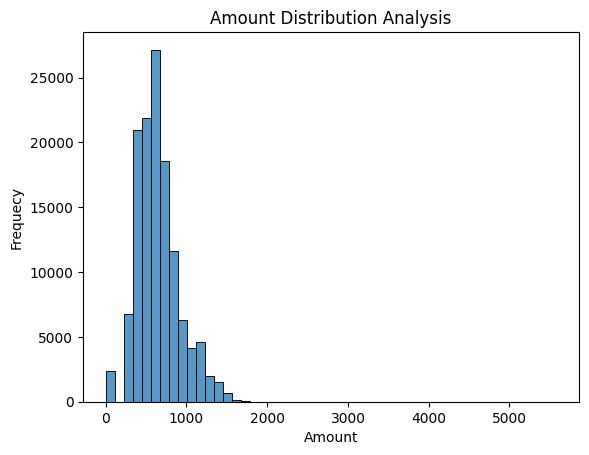

In [6]:
#Amount Distribution Analysis

plt.figure()
sns.histplot(df["Amount"],bins=50)
plt.title("Amount Distribution Analysis")
plt.xlabel("Amount")
plt.ylabel("Frequecy")
plt.savefig("graph1.png")
plt.show()

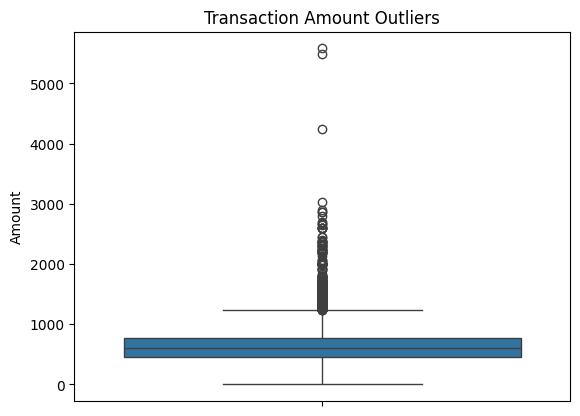

In [7]:
#Outlier Detection
plt.figure()
sns.boxplot(y=df['Amount'])
plt.title("Transaction Amount Outliers")
plt.show()


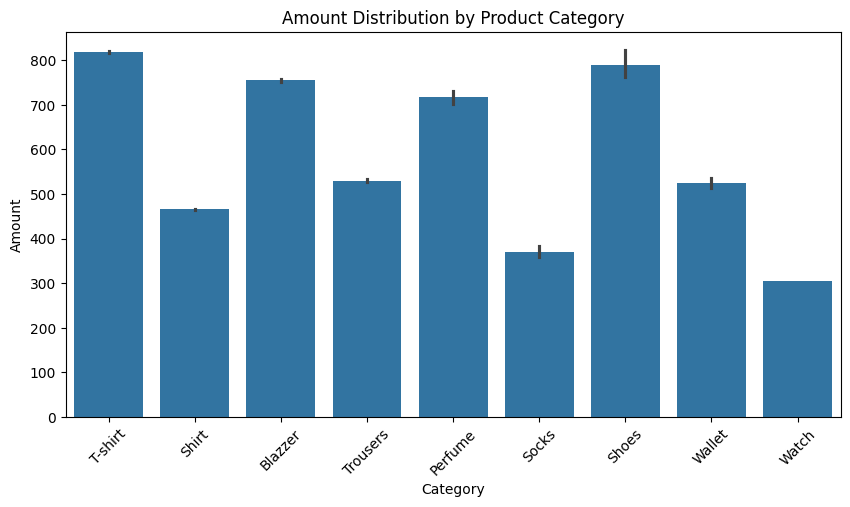

In [8]:
#Category-Wise Amount Analysis
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Amount', data=df)
plt.xticks(rotation=45)
plt.title("Amount Distribution by Product Category")
plt.show()

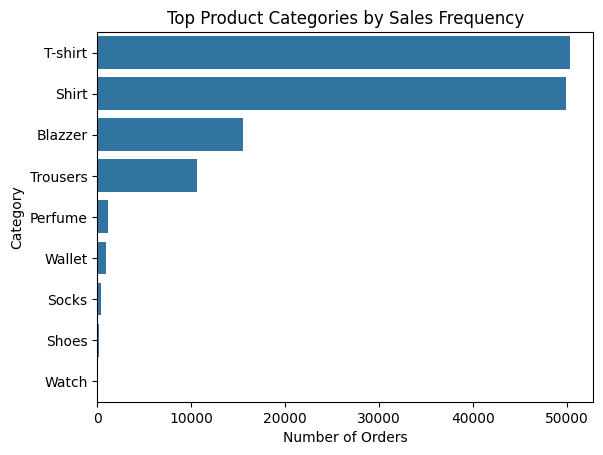

In [9]:
#Top Product Categories by Frequency
category_count = df["Category"].value_counts().head(10)
sns.barplot(x=category_count.values,y=category_count.index)
plt.title("Top Product Categories by Sales Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.show()

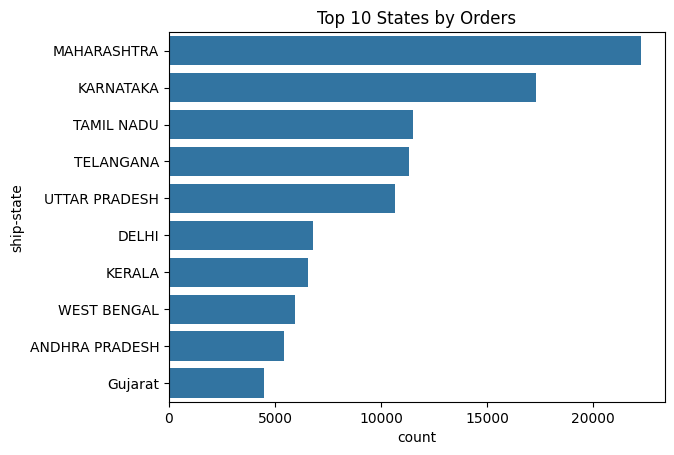

In [10]:
#Geographic Sales Analysis
df['ship-state'].value_counts().head(10)
sns.countplot(
    y='ship-state',
    data=df,
    order=df['ship-state'].value_counts().head(10).index
)
plt.title("Top 10 States by Orders")
plt.show()

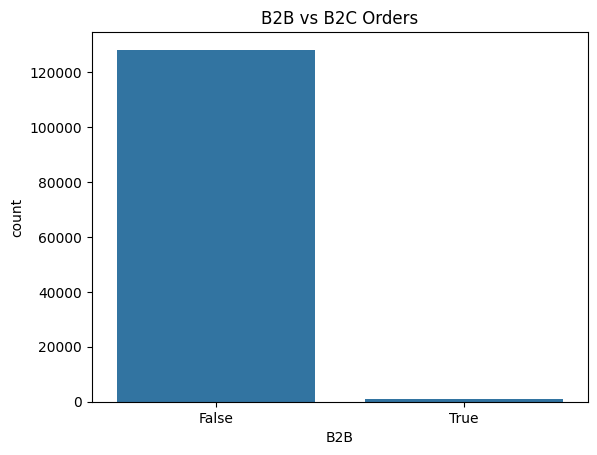

In [11]:
#B2B vs B2C Analysis
df['B2B'].value_counts(normalize=True) * 100
sns.countplot(x='B2B', data=df)
plt.title("B2B vs B2C Orders")
plt.show()

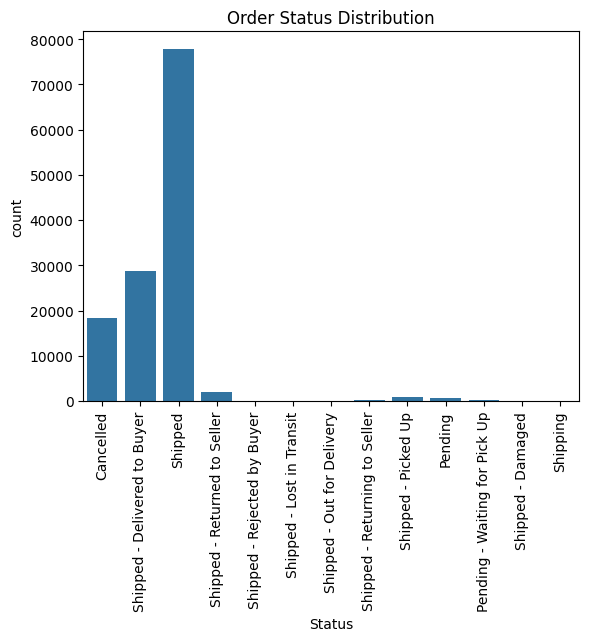

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
Fulfilment,,,,,,,,,,,,,
Amazon,11475,415,0,77815,0,0,0,0,0,0,0,0,8
Merchant,6859,243,281,0,1,28756,5,35,973,11,1954,145,0


In [12]:
#Order Status & Fulfilment Analysis
df['Courier Status'].value_counts()

pd.crosstab(df['fulfilled-by'], df['Courier Status'])


#Order Status & Fulfilment Analysis
df['Status'].value_counts()

sns.countplot(x='Status', data=df)
plt.title("Order Status Distribution")
plt.xticks(rotation=90)
plt.show()
pd.crosstab(df['Fulfilment'], df['Status'])

In [13]:
#Courier & Logistics Performance
df['Courier Status'].value_counts()

pd.crosstab(df['fulfilled-by'], df['Courier Status'])

Courier Status,Cancelled,On the Way,Shipped,Unshipped
fulfilled-by,,,,
Easy Ship,0,6870,31869,524
Not Specified,5940,0,77617,6156
